In [44]:
import baltic as bt
import pandas as pd
import numpy as np
import json
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import itertools
from collections import defaultdict
import statistics
import numpy as np
import re
import random
import math
import scipy.stats as stats
from collections import Counter
from scipy.stats import gaussian_kde
import seaborn as sns

In [45]:
json_path = "/Users/monclalab1/Documents/h3nx/analysis/treesort/pipeline/analyses/clock_rate/host_clock_rates.json"

with open(json_path) as f:
    host_stats = json.load(f)

In [46]:
print(host_stats)

{'na_avian': {'clock_rate': 0.0014153628923017929, 'root_yr': 1932.7972743811047}, 'eurasian_avian': {'clock_rate': 0.0010022429427303807, 'root_yr': 1925.5975498054086}, 'swine': {'clock_rate': 0.003923517661115446, 'root_yr': 1965.3744788462288}, 'canine': {'clock_rate': 0.0021760366926091234, 'root_yr': 2004.8254515694057}, 'human': {'clock_rate': 0.00417372439954042, 'root_yr': 1967.4178682706547}, 'equine': {'clock_rate': 0.001865099192944831, 'root_yr': 1954.4550337364963}}


In [47]:
clades = ['na_avian', 'eurasian_avian', 'swine', 'human']

In [48]:
host_trees = {}

for clade in clades:
    
    path = f'hosts/{clade}/summary_baltic.nwk'
    mytree= bt.loadNewick(path, absoluteTime= False)

    
    host_trees[clade] = mytree

In [49]:
# tree length check

rea_events = {"swine" : 442, "eurasian_avian" : 647}

for clade in ['eurasian_avian', 'swine']:
    
    tree_length = sum(node.length for node in host_trees[clade].Objects)
    
    rate_div = rea_events[clade] / tree_length # reassortments per substitutions per site
    
    rate_scaled = rate_div * host_stats[clade]['clock_rate']
    
    print(clade, tree_length, rate_div, rate_scaled)

eurasian_avian 6.408299999999992 100.9628138507874 0.1011892676601528
swine 11.708400000000047 37.75067472925406 0.14811543901925284


# reassorted lineages

In [50]:
# visit each reassorted node
# find how far it goes until another reassortment event or leaf
# sum all the edges
# keep that in a dictionary

In [51]:
def max_distance(node):
    """
    Return the maximum distance from `node` down to the first downstream
    reassortment OR a leaf, taken over all descendant paths.
    """

    if node.is_leaf() or node.traits.get('is_reassorted'):
        return node.length
    
    else:
        return node.length + max(max_distance(child) for child in node.children)

In [52]:
clade_persistences = {clade: {} for clade in host_trees.keys()}

for clade in clades:
    
    count = 0
    
    mytree = host_trees[clade] 
    reassortment_distances = {}
    
    for k in mytree.Objects:

        # skip leaves
        if k.is_leaf():
            continue

        # only look at reassorted nodes
        if k.is_node() and k.traits.get('is_reassorted'):
            
            count+=1

            children = k.children

            # if both children are reassorted or leaves, take max length, skip recursion
            if all(child.traits.get('is_reassorted') or child.is_leaf() for child in children):

                max_child_length = max(child.length for child in children)
                
            else:

                child_path_lengths = [max_distance(child) for child in children]
                max_child_length = max(child_path_lengths)

            reassortment_distances[k.traits["label"]] = {
                "height": k.height,
                "div": max_child_length,
                "scaled_distance": (max_child_length) / host_stats[clade]["clock_rate"],
                "branch_length": k.length,
            }

    print(clade,count)
    clade_persistences[clade] = reassortment_distances


na_avian 306
eurasian_avian 198
swine 150
human 26


In [53]:
na_avian_persistences = [
    v["scaled_distance"] for v in clade_persistences["na_avian"].values()
]

eu_avian_persistences = [
    v["scaled_distance"] for v in clade_persistences["eurasian_avian"].values()
]
swine_persistences = [
    v["scaled_distance"] for v in clade_persistences["swine"].values()
]

human_persistences = [
    v["scaled_distance"] for v in clade_persistences["human"].values()
]

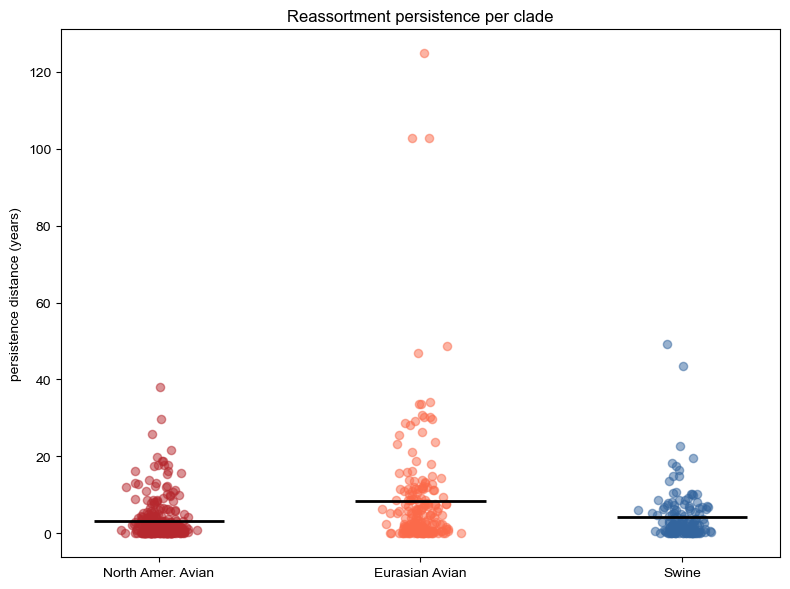

In [54]:
groups = ["North Amer. Avian", "Eurasian Avian", "Swine"]
data = [na_avian_persistences, eu_avian_persistences, swine_persistences]

color_map = {
    "North Amer. Avian": "#b6282e",
    "Eurasian Avian": "#fb6a4a", 
    "Swine": "#33659e"
    }

x = np.arange(len(groups))

plt.figure(figsize=(8, 6))

for i, (group, vals) in enumerate(zip(groups, data)):
    color = color_map[group]
    
    jitter = np.random.normal(0, 0.05, size=len(vals))
    plt.scatter(
        np.full(len(vals), x[i]) + jitter,
        vals,
        color=color,
        alpha=0.5,
        s=35
    )

    mean_val = np.mean(vals)
    plt.hlines(
        mean_val,
        x[i] - 0.25,
        x[i] + 0.25,
        colors="black",
        linewidth=2
    )

plt.xticks(x, groups)
plt.ylabel("persistence distance (years)")
plt.title("Reassortment persistence per clade")
plt.tight_layout()
plt.show()


In [55]:
def summarize(x):
    zero_count = sum(1 for val in x if val == 0.0)
    zero_prop = zero_count / len(x)
    
    return {
        "mean": np.mean(x),
        "sd": np.std(x, ddof=1),
        "median": np.median(x),
        "zeros": (zero_count, zero_prop)
    }

na_avian_stats = summarize(na_avian_persistences)
eu_avian_stats = summarize(eu_avian_persistences)
swine_stats = summarize(swine_persistences)

print("NA Avian:")
for k, v in na_avian_stats.items():
    if k == "zeros":
        print(f"  {k}: {v[0]}/{len(na_avian_persistences)} ({v[1]*100:.2f}%)")
    else:
        print(f"  {k}: {v:.2f}")
print(f"{len(na_avian_persistences)} lineages\n")
    
print("Eurasian Avian:")
for k, v in eu_avian_stats.items():
    if k == "zeros":
        print(f"  {k}: {v[0]}/{len(eu_avian_persistences)} ({v[1]*100:.2f}%)")
    else:
        print(f"  {k}: {v:.2f}")
print(f"{len(eu_avian_persistences)} lineages\n")

print("Swine:")
for k, v in swine_stats.items():
    if k == "zeros":
        print(f"  {k}: {v[0]}/{len(swine_persistences)} ({v[1]*100:.2f}%)")
    else:
        print(f"  {k}: {v:.2f}")
print(f"{len(swine_persistences)} lineages")

NA Avian:
  mean: 3.15
  sd: 5.10
  median: 1.22
  zeros: 69/306 (22.55%)
306 lineages

Eurasian Avian:
  mean: 8.37
  sd: 15.50
  median: 3.49
  zeros: 31/198 (15.66%)
198 lineages

Swine:
  mean: 4.22
  sd: 6.60
  median: 2.06
  zeros: 16/150 (10.67%)
150 lineages


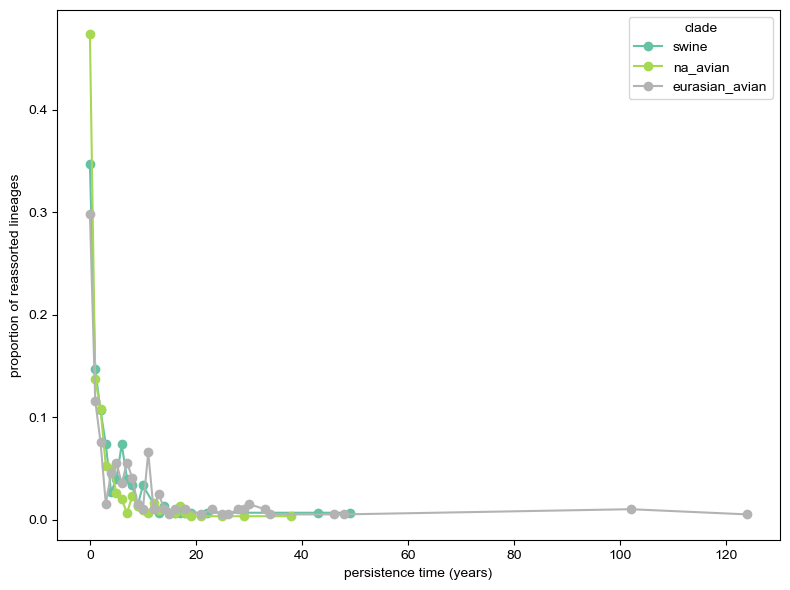

In [56]:
subset = ["swine", "na_avian", "eurasian_avian"]
filtered = {cl: clade_persistences[cl] for cl in subset}

colors = plt.cm.Set2(np.linspace(0, 1, len(filtered)))

plt.figure(figsize=(8, 6))

for (clade, persistences), color in zip(filtered.items(), colors):

    vals = np.array([v["scaled_distance"] for v in persistences.values()])
    
    # binned is an array of persistence times rounded down (floor) to whole years, like [1, 2, 2, 3, 1, 2]
    binned = np.floor(vals).astype(int)
    
    # Counter(binned) counts how many times each year occurs
    counts = Counter(binned)
    
    # total number of reassorted nodes
    total = len(vals)
    
    # sorted list of years that appear in counts
    years = np.array(sorted(counts.keys()))

    # for each year y, (counts[y] / total calculates) the fraction of nodes that had that persistence time
    proportions = np.array([counts[y] / total for y in years])

    plt.plot(
        years,
        proportions,
        marker="o",
        label=clade,
        color=color
    )

plt.xlabel("persistence time (years)")
plt.ylabel("proportion of reassorted lineages")
plt.legend(title="clade")
plt.tight_layout()
plt.show()


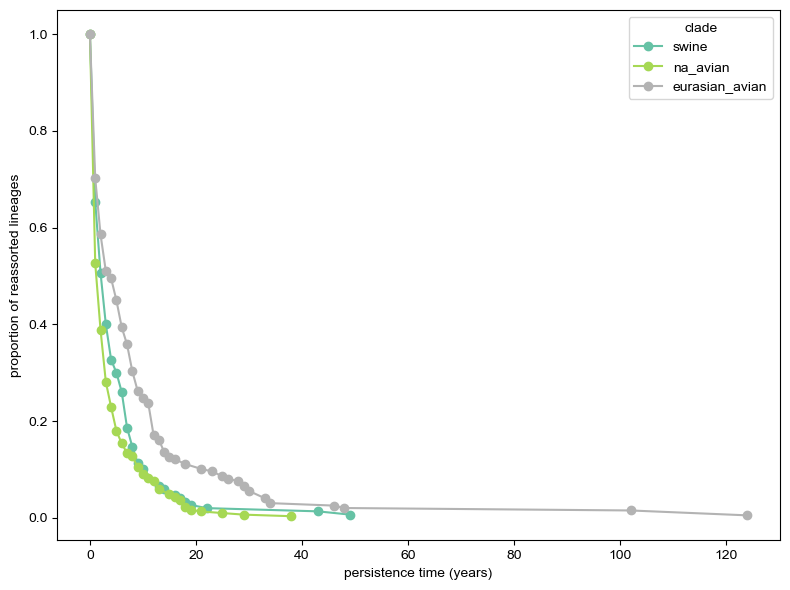

In [57]:
subset = ["swine", "na_avian", "eurasian_avian"]
filtered = {cl: clade_persistences[cl] for cl in subset}

colors = plt.cm.Set2(np.linspace(0, 1, len(filtered)))

plt.figure(figsize=(8, 6))

for (clade, persistences), color in zip(filtered.items(), colors):

    vals = np.array([v["scaled_distance"] for v in persistences.values()])
    
    binned = np.floor(vals).astype(int)
    counts = Counter(binned)
    
    total = len(vals)
    years = np.array(sorted(counts.keys()))
    proportions = np.array([counts[y] / total for y in years])

    # sum from the longest times backward:
    # [0.1, 0.1+0.2, 0.1+0.2+0.4, 0.1+0.2+0.4+0.3]
    # [0.1, 0.3, 0.7, 1.0]
    # then reverse back to original time order
    cumulative = np.cumsum(proportions[::-1])[::-1]

    plt.plot(
        years,
        cumulative,
        marker="o",
        label=clade,
        color=color
    )

plt.xlabel("persistence time (years)")
plt.ylabel("proportion of reassorted lineages")
plt.legend(title="clade")
plt.tight_layout()
plt.show()

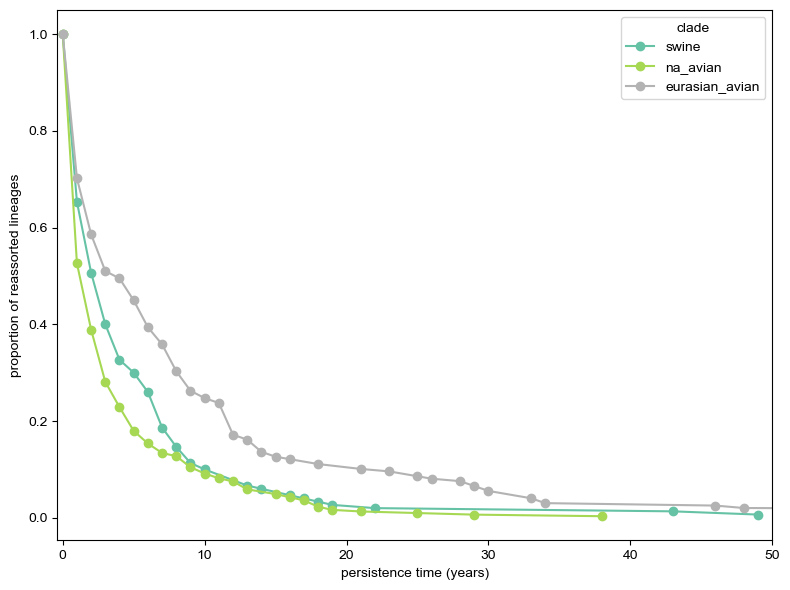

In [58]:
# subsetted to 50 years to zoom in on most reassorted lineages

subset = ["swine", "na_avian", "eurasian_avian"]
filtered = {cl: clade_persistences[cl] for cl in subset}

colors = plt.cm.Set2(np.linspace(0, 1, len(filtered)))

plt.figure(figsize=(8, 6))

for (clade, persistences), color in zip(filtered.items(), colors):

    vals = np.array([v["scaled_distance"] for v in persistences.values()])
    
    binned = np.floor(vals).astype(int)
    counts = Counter(binned)
    
    total = len(vals)
    years = np.array(sorted(counts.keys()))
    proportions = np.array([counts[y] / total for y in years])

    # Convert to cumulative (survival curve)
    cumulative = np.cumsum(proportions[::-1])[::-1]

    plt.plot(
        years,
        cumulative,
        marker="o",
        label=clade,
        color=color
    )

plt.xlabel("persistence time (years)")
plt.xlim(-0.4, 50)
plt.ylabel("proportion of reassorted lineages")
plt.legend(title="clade")
plt.tight_layout()
plt.show()



# nonreassorted lineages

In [59]:
nonrea_clade_persistences = {clade: {} for clade in host_trees.keys()}

for clade in clades:
    
    mytree = host_trees[clade] 
    nonreassortment_distances = {}
    
    for k in mytree.Objects:

        # skip leaves
        if k.is_leaf():
            continue

        # only look at nonreassorted nodes
        if k.is_node() and not k.traits.get('is_reassorted'):

            children = k.children

            # if both children are reassorted or leaves, take max length, skip recursion
            if all(child.traits.get('is_reassorted') or child.is_leaf() for child in children):

                max_child_length = max(child.length for child in children)
                
            else:

                child_path_lengths = [max_distance(child) for child in children]
                max_child_length = max(child_path_lengths)

            nonreassortment_distances[k.traits["label"]] = {
                "height": k.height,
                "div": max_child_length,
                "scaled_distance": max_child_length / host_stats[clade]["clock_rate"],
                "branch_length": k.length,
            }


    nonrea_clade_persistences[clade] = nonreassortment_distances


# both

In [60]:
scaled_clade_persistences = {
    clade: {node: vals["scaled_distance"] for node, vals in nodes.items()}
    for clade, nodes in clade_persistences.items()
}

scaled_nonrea_persistences = {
    clade: {node: vals["scaled_distance"] for node, vals in nodes.items()}
    for clade, nodes in nonrea_clade_persistences.items()
}

In [61]:
def get_binned_proportions(persistences):
    """
    persistences: list or array of numbers
    returns: (years, cumulative_proportions) as a survival curve
    """
    persistences = np.array(list(persistences))
    binned = np.floor(persistences).astype(int)
    counts = Counter(binned)
    total = len(binned)
    years = np.array(sorted(counts.keys()))
    proportions = np.array([counts[y] / total for y in years])
    
    # sum from the longest times backward:
    # [0.1, 0.1+0.2, 0.1+0.2+0.4, 0.1+0.2+0.4+0.3]
    # [0.1, 0.3, 0.7, 1.0]
    # then reverse back to original time order
    cumulative = np.cumsum(proportions[::-1])[::-1]
    
    return years, cumulative

In [62]:
with open("jsons/nonrea_clade_persistences.json", "r") as f:
    nonrea_clade_persistences = json.load(f)

with open("jsons/clade_persistences.json", "r") as f:
    clade_persistences = json.load(f)

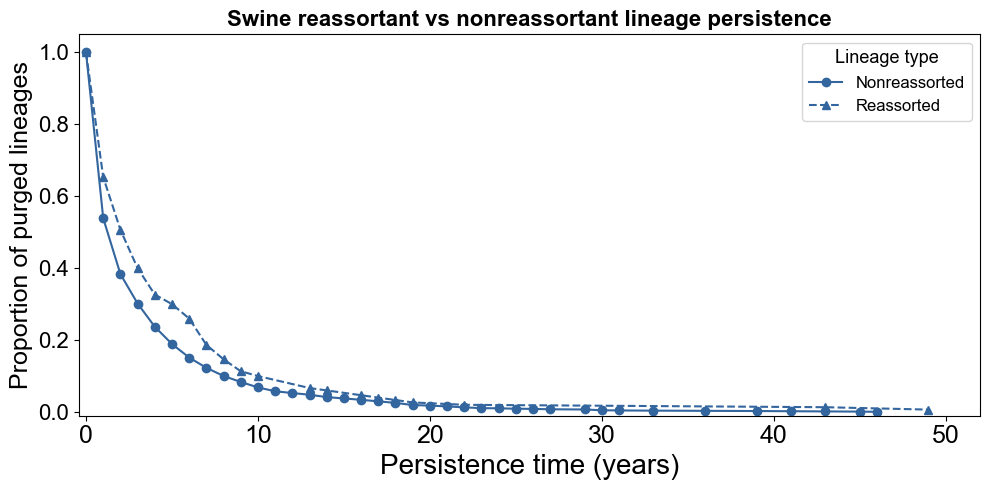

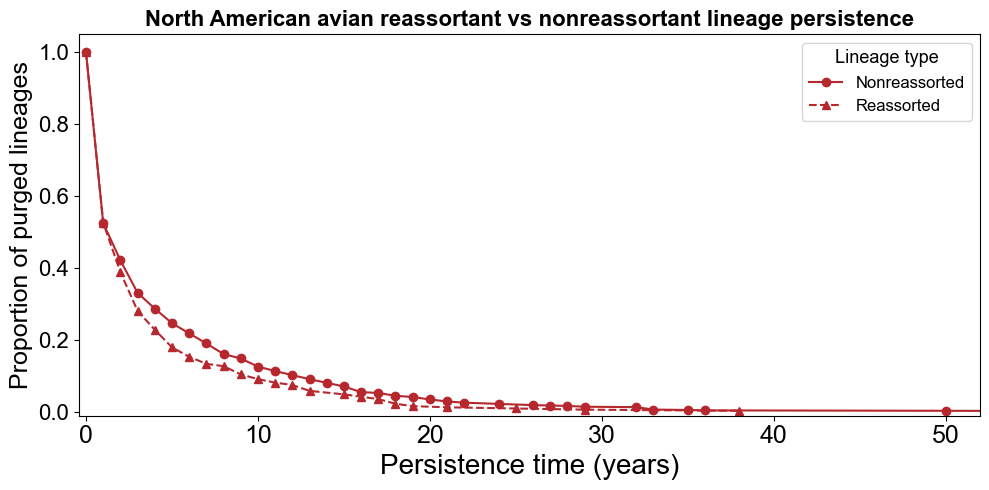

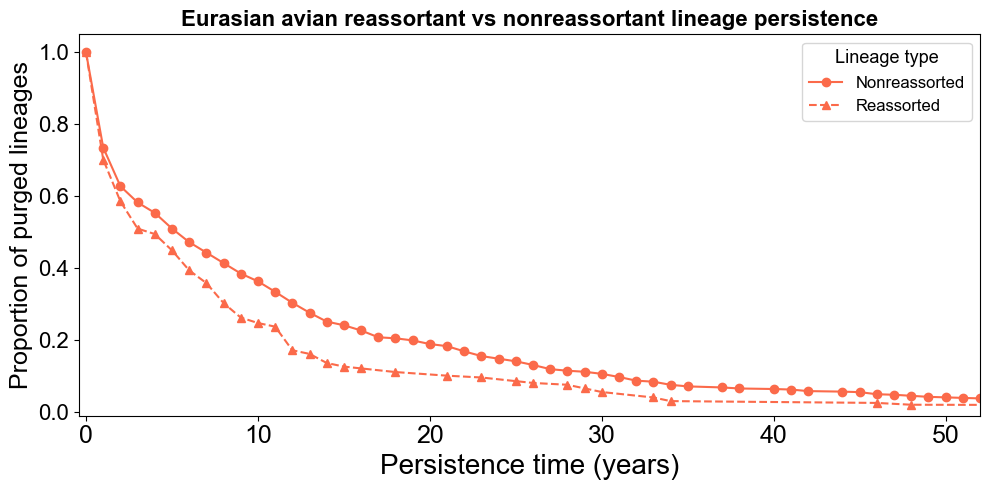

In [63]:
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Arial'

subset = ["swine", "na_avian", "eurasian_avian"]

colors = {
    "na_avian": "#b6282e",
    "eurasian_avian": "#fb6a4a",
    "swine": "#33659e"
}

labels = {
    "na_avian": "North American avian",
    "eurasian_avian": "Eurasian avian",
    "swine": "Swine"
}

for clade in subset:
    plt.figure(figsize=(10, 5))

    # non-reassorted (circles)
    years, proportions = get_binned_proportions(scaled_nonrea_persistences[clade].values())
    plt.plot(
        years,
        proportions,
        marker="o",
        linestyle="-",
        color=colors[clade],
        label="Nonreassorted"
    )

    # reassorted (triangles)
    years, proportions = get_binned_proportions(scaled_clade_persistences[clade].values())
    plt.plot(
        years,
        proportions,
        marker="^",
        linestyle="--",
        color=colors[clade],
        label="Reassorted"
    )

    plt.xlabel("Persistence time (years)", fontsize=20)
    plt.ylabel("Proportion of purged lineages", fontsize=18)
    plt.title(
        f"{labels[clade]} reassortant vs nonreassortant lineage persistence",
        fontsize=16,
        fontweight="bold"
    )
    plt.xlim(-0.4, 52)
    plt.ylim(-0.01, 1.05)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=16)
    plt.legend(title="Lineage type", fontsize=12, title_fontsize=13)
    plt.tight_layout()
    plt.savefig(f"plots/{clade}_persistences_vs_nonrea.pdf", dpi=300, bbox_inches="tight")
    plt.show()

In [64]:
def get_binned_proportions_replicates(all_replicates):
    """
    all_replicates: list of lists of persistence times for each replicate
    returns: bins (only bins that appear), mean_proportions, lower_ci, upper_ci (as survival curve)
    """
    replicate_props = []
    replicate_bins = []

    for rep in all_replicates:
        rep = np.array(rep)
        binned = np.floor(rep).astype(int)
        counts = Counter(binned)
        total = len(binned)
        bins = np.array(sorted(counts.keys()))
        proportions = np.array([counts[b]/total for b in bins])
        
        # Convert to cumulative survival curve
        cumulative = np.cumsum(proportions[::-1])[::-1]
        
        replicate_props.append(cumulative)
        replicate_bins.append(bins)

    all_bins = sorted(set(np.concatenate(replicate_bins))) # union of all bins
    mean_props = []
    lower_ci = []
    upper_ci = []

    for b in all_bins:
        props = np.array([rep_props[rep_bins.tolist().index(b)] if b in rep_bins else np.nan
                          for rep_props, rep_bins in zip(replicate_props, replicate_bins)])
        # Calculate statistics, ignoring NaN values for missing bins
        valid_props = props[~np.isnan(props)]
        mean_props.append(np.mean(valid_props))
        lower_ci.append(np.percentile(valid_props, 5))
        upper_ci.append(np.percentile(valid_props, 95))

    return np.array(all_bins), np.array(mean_props), np.array(lower_ci), np.array(upper_ci)

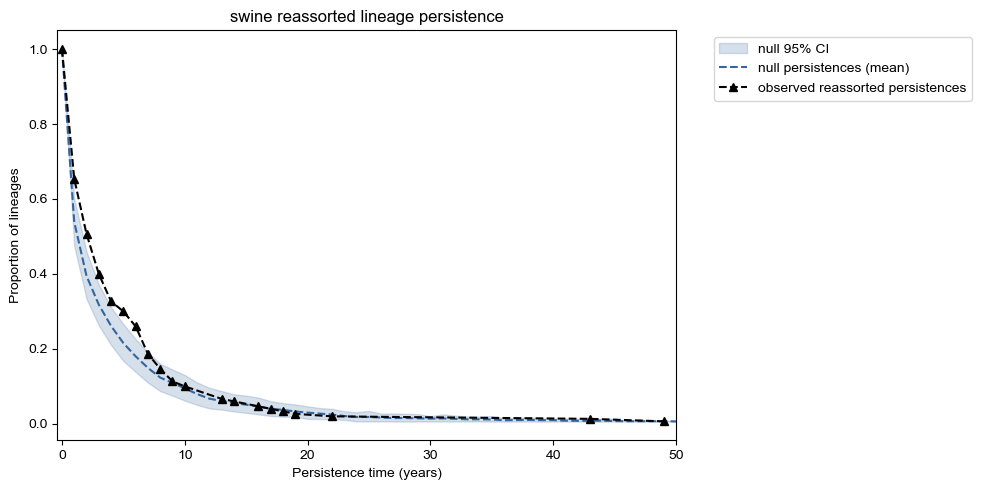

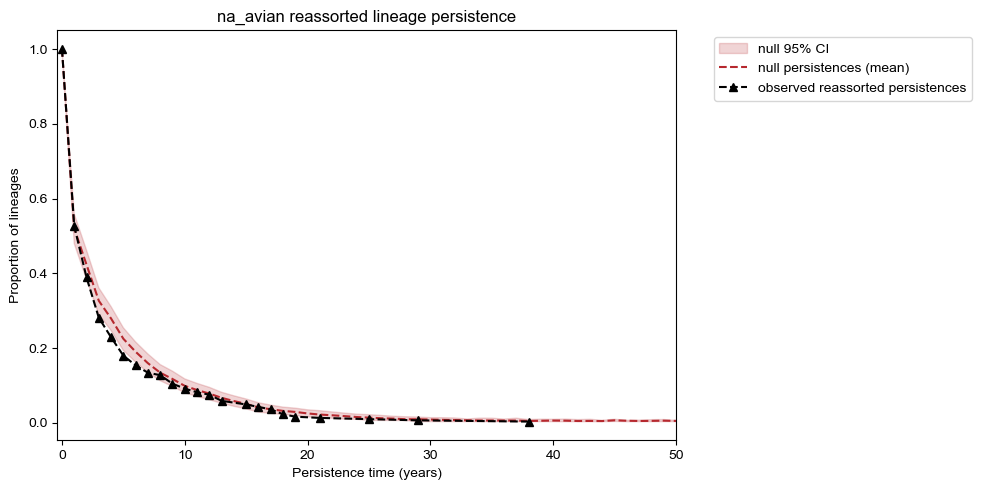

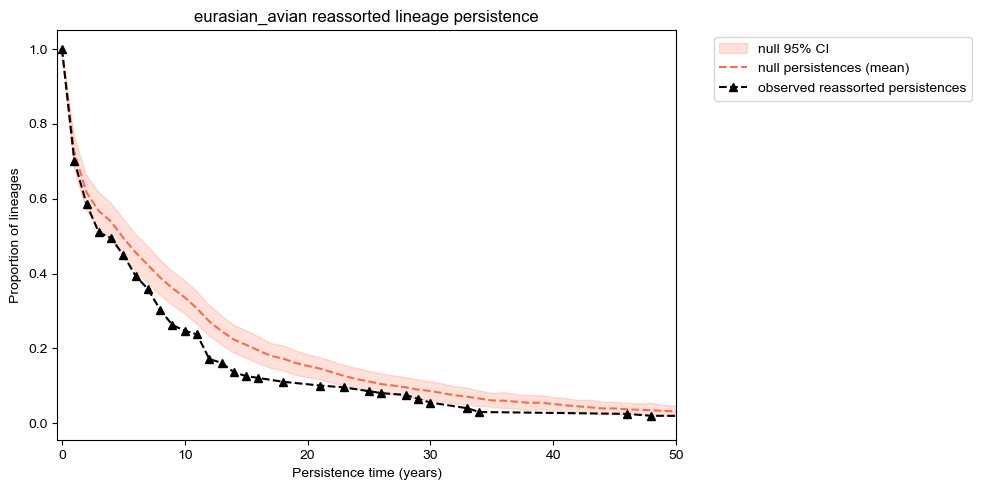

In [65]:
colors = {
    "na_avian": "#b6282e",
    "eurasian_avian": "#fb6a4a",
    "swine": "#33659e"
}

for clade in subset:
    plt.figure(figsize=(10, 5))

    # reassorted replicate mean + CI
    bins, mean_props, lower_ci, upper_ci = get_binned_proportions_replicates(
        clade_persistences[clade].values()
    )
    plt.fill_between(bins, lower_ci, upper_ci, color=colors[clade], alpha=0.2, label=f"null 95% CI")
    plt.plot(bins, mean_props, color=colors[clade], linestyle='--', label=f"null persistences (mean)")

    # reassorted scaled values (single values)
    years, proportions = get_binned_proportions(scaled_clade_persistences[clade].values())
    plt.plot(years, proportions, marker="^", linestyle="--", color='black', label=f"observed reassorted persistences")

    plt.xlabel("Persistence time (years)")
    plt.ylabel("Proportion of lineages")
    plt.title(f"{clade} reassorted lineage persistence")
    plt.xlim(-0.4, 50)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(f"plots/{clade}_persistences_vs_null.pdf", dpi=300, bbox_inches="tight")
    plt.show()

In [66]:
# 1-year proportions for each clade
for clade in subset:
    years, proportions = get_binned_proportions(scaled_clade_persistences[clade].values())
    
    idx_1yr = np.searchsorted(years, 1.0)
    
    # proportion surviving ≥1 year
    survival_1yr = proportions[idx_1yr] 
    
    # proportion purged in first year = 1 - survival
    purged_1yr = 1 - survival_1yr
    print(f"{clade}: {purged_1yr*100:.1f}% lineages purged in first year")

# for swine, also get the null expectation at 1yr
clade = "swine"
bins, mean_props, lower_ci, upper_ci = get_binned_proportions_replicates(
    clade_persistences[clade].values()
)

# find bin 1 in the null distribution
idx_1yr_null = np.searchsorted(bins, 1.0)
null_survival_1yr = mean_props[idx_1yr_null] 
null_purged_1yr = 1 - null_survival_1yr

obs_purged_1yr = purged_1yr
difference = (obs_purged_1yr - null_purged_1yr) * 100
print(f"swine: {difference:.1f}% {'less' if difference > 0 else 'more'} survived than in null (observed: {obs_purged_1yr*100:.1f}%, null: {null_purged_1yr*100:.1f}%)")

swine: 34.7% lineages purged in first year
na_avian: 47.4% lineages purged in first year
eurasian_avian: 29.8% lineages purged in first year
swine: -16.4% more survived than in null (observed: 29.8%, null: 46.2%)


In [67]:
# 5-year proportions for each clade
for clade in subset:
    years, proportions = get_binned_proportions(scaled_clade_persistences[clade].values())
    
    idx_5yr = np.searchsorted(years, 5.0)
    
    # proportion surviving ≥5 years
    survival_5yr = proportions[idx_5yr]
    
    # [roportion purged in first 5 years = 1 - survival
    purged_5yr = 1 - survival_5yr
    print(f"{clade}: {purged_5yr*100:.1f}% lineages purged in first 5 years")

# For swine, also get the null expectation at 5yr
clade = "swine"
bins, mean_props, lower_ci, upper_ci = get_binned_proportions_replicates(
    clade_persistences[clade].values()
)

# bin 5 in the null distribution
idx_5yr_null = np.searchsorted(bins, 5.0)
null_survival_5yr = mean_props[idx_5yr_null]
null_purged_5yr = 1 - null_survival_5yr

obs_purged_5yr = purged_5yr
difference = (obs_purged_5yr - null_purged_5yr) * 100
print(f"swine: {difference:.1f}% {'less' if difference > 0 else 'more'} survived than in null (observed: {obs_purged_5yr*100:.1f}%, null: {null_purged_5yr*100:.1f}%)")

swine: 70.0% lineages purged in first 5 years
na_avian: 82.0% lineages purged in first 5 years
eurasian_avian: 55.1% lineages purged in first 5 years
swine: -23.4% more survived than in null (observed: 55.1%, null: 78.5%)
